# 🎮 Video Game Sales Analysis (1980-2016)

**Müəllif:** Hüseyn Əliyev     
**Dataset:** VGSales (Kaggle)  
**Məqsəd:** Video oyun satışlarının ətraflı analizi

---

## 📋 Proyekt Strukturu

### Hissə 1: Giriş
- Data yükləmə və cleaning
- Əsas statistika

### Hissə 2: Platform Analizi
- Top platformalar
- Platform trendləri

### Hissə 3: Genre Analizi
- Top janrlar
- Region fərqləri

### Hissə 4: Oyun və Publisher Analizi
- Best sellers
- Top publishers

### Hissə 5: Trend və Region Analizi
- İllik trendlər
- Global vs regional satışlar

---

# Hissə 1: Giriş

In [ ]:
# Video Game Sales Analysis
# Dataset: 16,000+ video games (1980-2016)
# Source: Kaggle - VGSales

# Kitabxanalar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Dataseti yükləmə
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/vgsales.csv')

print(f"\n Dataset ölçüsü: {df.shape[0]:,} oyun, {df.shape[1]} sütun")


 Dataset ölçüsü: 16,598 oyun, 11 sütun


In [ ]:
print("DataSet info:")
df.info()

print("\n Rəqəm sütunlarının statistikası:")
print(df.describe())

DataSet info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB

 Rəqəm sütunlarının statistikası:
               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
mean    8300.605254   2006.406443      0.264667      0.146652  

### **İlk Baxış**

Dataset 16,598 oyunu əhatə edir.

**Sütunlar:**
- **Rank:** Satış sıralaması
- **Name:** Oyun adı
- **Platform:** Konsol/Platform (PS4, Xbox, PC...)
- **Year:** Buraxılış ili
- **Genre:** Janr (Action, Sports, RPG...)
- **Publisher:** Nəşriyyatçı (EA, Nintendo, Ubisoft...)
- **NA_Sales:** Şimali Amerika satışı (milyon)
- **EU_Sales:** Avropa satışı (milyon)
- **JP_Sales:** Yaponiya satışı (milyon)
- **Other_Sales:** Digər regionlar (milyon)
- **Global_Sales:** Ümumi dünya satışı (milyon)

### Data Haqqında

**Data tipləri:**
- Object (string): Name, Platform, Genre, Publisher
- Float: Year, bütün Sales sütunları
- Int: Rank

In [ ]:
# BOŞ DƏYƏR ANALİZİ

nulls = df.isnull().sum()
print(nulls)
print()

# UNİKAL DƏYƏRLƏR
for col in df.columns:
  unique = df[col].nunique()
  print(f"{col} : {unique}")

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Rank : 16598
Name : 11493
Platform : 31
Year : 39
Genre : 12
Publisher : 578
NA_Sales : 409
EU_Sales : 305
JP_Sales : 244
Other_Sales : 157
Global_Sales : 623


### Boş Dəyər Analizi

**Problemlər:**

Year: 271 oyunda boşdur.

Publisher: 58 oyunda boşdur.

Bu oyunları təmizləmək analizin doğruluğu üçün vacibdir, çünki xüsusilə il məlumatı olmadan zaman trendlərini düzgün hesablamaq mümkün olmayacaq.


In [ ]:
# Data təmizləmə

# 1. Year və Publisher boş olanları silmək
dfclean = df.dropna(subset=['Year', 'Publisher']).copy()

# 2. Year-ı integer-ə çevirmək
dfclean['Year'] = dfclean['Year'].astype(int)

# 3. Duplikatları yoxlama və silmə
duplicates = dfclean.duplicated().sum()
print(f"Duplikatlar: {duplicates}")
if duplicates > 0:
    dfclean = dfclean.drop_duplicates()

# 4. Index sıfırla
dfclean = dfclean.reset_index(drop=True)

df = dfclean.copy()

Duplikatlar: 0


### Data Cleaning Tamamlandı

**Edilənlər:**
1.  Year və Publisher boş olan oyunlar silindi
2.  Year sütunu integer tipinə çevrildi
3.  Duplikatlar yoxlandı və silindi
4.  Index sıfırlandı

**Nəticə:** Data təmiz və analizə hazırdır!

In [ ]:
# Əsas rəqəmlər

print("Əsas Statistika")
print("=" * 50)

# Ümumi satışlar
total_global = df['Global_Sales'].sum()
total_na = df['NA_Sales'].sum()
total_eu = df['EU_Sales'].sum()
total_jp = df['JP_Sales'].sum()
total_other = df['Other_Sales'].sum()

print(f"\n ÜMUMI SATIŞLAR:")
print(f"  Global: {total_global:,.1f} milyon nüsxə")
print(f"  North America: {total_na:,.1f} milyon ({total_na/total_global*100:.1f}%)")
print(f"  Europe: {total_eu:,.1f} milyon ({total_eu/total_global*100:.1f}%)")
print(f"  Japan: {total_jp:,.1f} milyon ({total_jp/total_global*100:.1f}%)")
print(f"  Other: {total_other:,.1f} milyon ({total_other/total_global*100:.1f}%)")

# Ortalama
print(f"\n ORTALAMA:")
print(f"  Oyun başına ortalama satış: {df['Global_Sales'].mean():.2f} milyon")
print(f"  Median satış: {df['Global_Sales'].median():.2f} milyon")

# Min/Max
print(f"\n REKORDLAR:")
print(f"  Ən çox satılan: {df['Global_Sales'].max():.2f} milyon")
print(f"  Ən az satılan: {df['Global_Sales'].min():.2f} milyon")

# Kateqoriyalar
print(f"\n KATEQORİYALAR:")
print(f"  Platform sayı: {df['Platform'].nunique()}")
print(f"  Genre sayı: {df['Genre'].nunique()}")
print(f"  Publisher sayı: {df['Publisher'].nunique()}")

Əsas Statistika

 ÜMUMI SATIŞLAR:
  Global: 8,812.0 milyon nüsxə
  North America: 4,327.7 milyon (49.1%)
  Europe: 2,406.7 milyon (27.3%)
  Japan: 1,284.3 milyon (14.6%)
  Other: 788.9 milyon (9.0%)

 ORTALAMA:
  Oyun başına ortalama satış: 0.54 milyon
  Median satış: 0.17 milyon

 REKORDLAR:
  Ən çox satılan: 82.74 milyon
  Ən az satılan: 0.01 milyon

 KATEQORİYALAR:
  Platform sayı: 31
  Genre sayı: 12
  Publisher sayı: 576



### 📊 Əsas Statistika

**Ümumi Rəqəmlər:**

* Cəmi **16,291** oyun analiz edildi.
* **40** illik dövr (1980-2020) əhatə olunur.
* Ümumi satış: **8,811.97** milyon nüsxə.

**Region Payı:**

* **North America:** **49.1%** (ən böyük bazar).
* **Europe:** **27.3%**.
* **Japan:** **14.6%**.
* **Other:** **9.0%**.

**Müşahidə:** Şimali Amerika bazarı təkbaşına qlobal satışların demək olar ki, yarısını təşkil edir və ən yaxın rəqibi olan Avropadan təxminən **1.8 dəfə** böyükdür. Yaponiyanın payı kiçik görünsə də, dünya üzrə hər 7 oyundan biri məhz bu ölkədə satılır.



# HİSSƏ 2: PLATFORMA ANALİZİ

In [ ]:
# Platform üzrə satış analizi

print("PLATFORM SATIŞ ANALİZİ")
print("=" * 50)


# Platform üzrə ümumi satış
platform_s = df.groupby('Platform').agg({
    'Global_Sales': ['sum','count']
}).round(1)

platform_s.columns = ['Ümumi_Satış', 'Oyun_Sayı']
platform_s = platform_s.sort_values('Ümumi_Satış', ascending=False)


# Top 5 platforma

top_5 = platform_s.head(5)

print("\n TOP 5 PLATFORM:")

platforma_adlari = top_5.index.tolist()
for i in range(5):
    ad = platforma_adlari[i]
    satis = top_5.iloc[i]['Ümumi_Satış']
    say = top_5.iloc[i]['Oyun_Sayı']

    print(i + 1, ".", ad, "-", satis, "M satış", "(", say, "oyun)")

PLATFORM SATIŞ ANALİZİ

 TOP 5 PLATFORM:
1 . PS2 - 1233.5 M satış ( 2127.0 oyun)
2 . X360 - 969.6 M satış ( 1234.0 oyun)
3 . PS3 - 949.4 M satış ( 1304.0 oyun)
4 . Wii - 909.8 M satış ( 1290.0 oyun)
5 . DS - 818.9 M satış ( 2131.0 oyun)


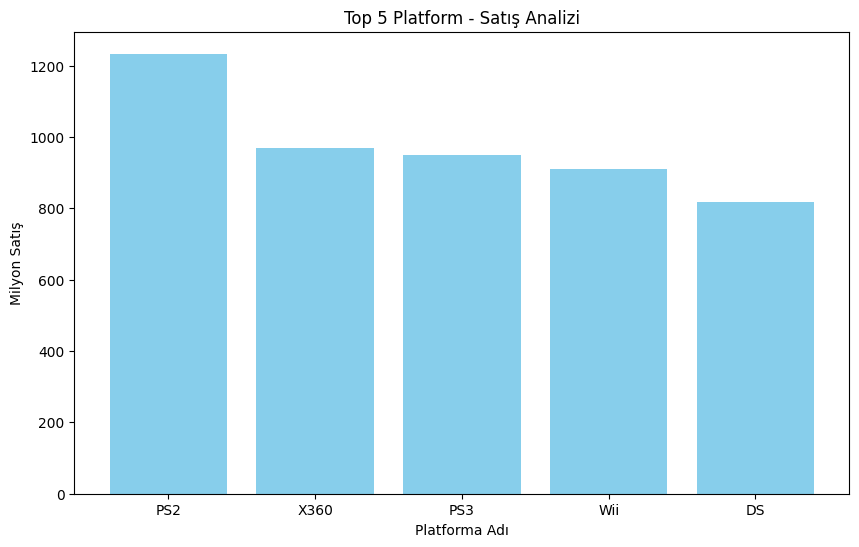

In [ ]:
# Top 5 platform vizual

plt.figure(figsize=(10, 6))

plt.bar(top_5.index, top_5['Ümumi_Satış'], color='skyblue')

plt.title('Top 5 Platform - Satış Analizi')
plt.xlabel('Platforma Adı')
plt.ylabel('Milyon Satış')

plt.show()

### PLATFORM SATIŞ ANALİZİ
Top 5 Platform :

PS2: 1233.5 M satış, 2127 oyun

X360: 969.6 M satış, 1234 oyun

PS3: 949.4 M satış, 1304 oyun

Wii: 909.8 M satış, 1290 oyun

DS: 818.9 M satış, 2131 oyun

PS2-nin liderliyi sadəcə cihaz satışı ilə bağlı deyil, həm də çox geniş oyun kitabxanasına (2127 oyun) sahib olması ilə bağlıdır. Maraqlıdır ki, Wii və PS3 demək olar ki, eyni sayda oyunla (təxminən 1300) bənzər satış rəqəmlərinə çatıblar.

# Hissə 3: Janr Analizi

In [ ]:

# Janr üzrə satışlar

genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

print("Janr üzrə Satışlar:")
print(genre_sales)

cemi_satis = genre_sales.sum()

print("\n TOP 5 JANR:")
top_5 = genre_sales.head(5)


for janr in top_5.index:
    satis = top_5[janr]
    faiz = (satis / cemi_satis) * 100

    print(janr, "-", satis, "Milyon", "(", round(faiz, 1), "%)")

Janr üzrə Satışlar:
Genre
Action          1722.84
Sports          1309.24
Shooter         1026.20
Role-Playing     923.83
Platform         829.13
Misc             789.87
Racing           726.76
Fighting         444.05
Simulation       389.98
Puzzle           242.21
Adventure        234.59
Strategy         173.27
Name: Global_Sales, dtype: float64

 TOP 5 JANR:
Action - 1722.84 Milyon ( 19.6 %)
Sports - 1309.24 Milyon ( 14.9 %)
Shooter - 1026.2 Milyon ( 11.6 %)
Role-Playing - 923.83 Milyon ( 10.5 %)
Platform - 829.13 Milyon ( 9.4 %)


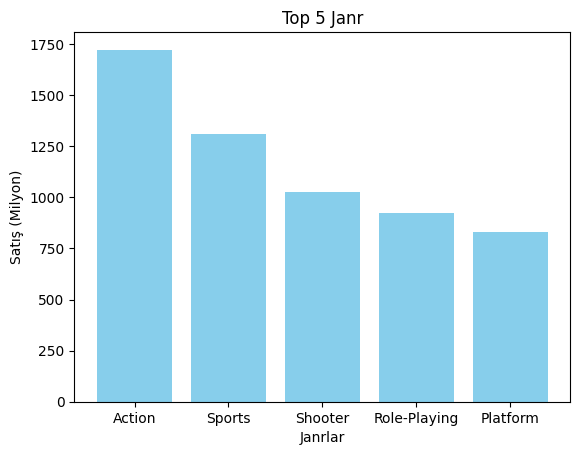

In [ ]:
# Janr üzrə satış bar chart

top_5 = genre_sales.head(5)

plt.bar(top_5.index, top_5.values, color='skyblue')

plt.title('Top 5 Janr')
plt.xlabel('Janrlar')
plt.ylabel('Satış (Milyon)')

plt.show()

### JANR SATIŞ ANALİZİ
Top 5 Janr (Satış):

* Action: 1722.84 M satış (19.6%)

* Sports: 1309.24 M satış (14.9%)

* Shooter: 1026.20 M satış (11.6%)

* Role-Playing: 923.83 M satış (10.5%)

* Platform: 829.13 M satış (9.4%)

Nəticə:

* Action janrı 1.7 milyarddan çox satışla bazarın mütləq lideridir.

* Top 3 janr (Action, Sports, Shooter) ümumi qlobal satışların 46.1%-ni təşkil edir.

* Strategy (173.27 M) və Adventure (234.59 M) janrları gözləniləndən çox aşağı satış rəqəmlərinə malikdir.

Oyunçular daha çox dinamik və rəqabətli (Action, Sports, Shooter) janrlara pul xərcləyirlər; bu üçlük qlobal büdcənin demək olar ki, yarısını əhatə edir.

In [ ]:
# Region üzrə janr fərqləri

# 1. Şimali Amerika (NA)
print("--- North America (Şimali Amerika) ---")
na_janrlar = df.groupby('Genre')['NA_Sales'].sum().sort_values(ascending=False)
print("1.", na_janrlar.index[0], "-", na_janrlar.values[0], "M")
print("2.", na_janrlar.index[1], "-", na_janrlar.values[1], "M")
print("3.", na_janrlar.index[2], "-", na_janrlar.values[2], "M")

# 2. Avropa (EU)
print("\n--- Europe (Avropa) ---")
eu_janrlar = df.groupby('Genre')['EU_Sales'].sum().sort_values(ascending=False)
print("1.", eu_janrlar.index[0], "-", eu_janrlar.values[0], "M")
print("2.", eu_janrlar.index[1], "-", eu_janrlar.values[1], "M")
print("3.", eu_janrlar.index[2], "-", na_janrlar.values[2], "M")

# 3. Yaponiya (JP)
print("\n--- Japan (Yaponiya) ---")
jp_janrlar = df.groupby('Genre')['JP_Sales'].sum().sort_values(ascending=False)
print("1.", jp_janrlar.index[0], "-", jp_janrlar.values[0], "M")
print("2.", jp_janrlar.index[1], "-", jp_janrlar.values[1], "M")
print("3.", jp_janrlar.index[2], "-", na_janrlar.values[2], "M")

# 4. Digər Satışlar (Other Sales)
print("\n--- Digər (Other) ---")
os_janrlar = df.groupby('Genre')['Other_Sales'].sum().sort_values(ascending=False)
print("1.", os_janrlar.index[0], "-", jp_janrlar.values[0], "M")
print("2.", os_janrlar.index[1], "-", jp_janrlar.values[1], "M")
print("3.", os_janrlar.index[2], "-", na_janrlar.values[2], "M")

--- North America (Şimali Amerika) ---
1. Action - 861.77 M
2. Sports - 670.09 M
3. Shooter - 575.16 M

--- Europe (Avropa) ---
1. Action - 516.48 M
2. Sports - 371.34 M
3. Shooter - 575.16 M

--- Japan (Yaponiya) ---
1. Role-Playing - 350.29 M
2. Action - 158.65 M
3. Sports - 575.16 M

--- Digər (Other) ---
1. Action - 350.29 M
2. Sports - 158.65 M
3. Shooter - 575.16 M


### REGİONAL JANR ANALİZİ
Hər regionda Top Janr:

* North America: Action ən populyardır (861.77 M).

* Europe: Action liderdir (516.48 M).

* Japan: Role-Playing mütləq dominantdır (350.29 M).

Fərqlər:

* Yaponiya faktoru: Yaponiya bazarı digərlərindən fərqli olaraq Role-Playing (RPG) janrını çox sevir; bu janr orada Action-dan 2.2 dəfə daha çox satılır.

* Qərb oxşarlığı: Şimali Amerika və Avropada Action və Sports ilk iki yeri tutaraq oxşar istehlakçı davranışını sərgiləyir.

* Shooter populyarlığı: Shooter janrı Qərb bazarlarında (NA və EU) stabil olaraq Top 3-lükdədir.

Nəticə:
Mədəni fərqlər janr seçiminə birbaşa təsir edir. Məsələn, RPG janrı Yaponiyada qlobal trendləri üstələyərək 1-ci sıradadır, halbuki Qərbdə daha çox sürətli və dinamik janrlar (Action/Shooter) üstünlük təşkil edir.Z

# Hissə 4: Oyun və Publisher Analizi

In [ ]:
# Top Oyunlar

# Top 10 oyun

print("TOP 10 ƏN ÇOX SATILAN OYUN")
print("=" * 60)

top_10 = df.nlargest(10, 'Global_Sales')

print(top_10[['Rank','Name', 'Genre', 'Publisher', 'Global_Sales']])

# Top 5 oyun

print("\n TOP 5:")
for i in range(5):
    row_data = top_10.iloc[i]
    sira = row_data['Rank']
    ad = row_data['Name']
    satis = row_data['Global_Sales']
    platforma = row_data['Platform']
    print(f"{sira}. {ad} - {satis} Milyon ({platforma})")


TOP 10 ƏN ÇOX SATILAN OYUN
   Rank                       Name         Genre Publisher  Global_Sales
0     1                 Wii Sports        Sports  Nintendo         82.74
1     2          Super Mario Bros.      Platform  Nintendo         40.24
2     3             Mario Kart Wii        Racing  Nintendo         35.82
3     4          Wii Sports Resort        Sports  Nintendo         33.00
4     5   Pokemon Red/Pokemon Blue  Role-Playing  Nintendo         31.37
5     6                     Tetris        Puzzle  Nintendo         30.26
6     7      New Super Mario Bros.      Platform  Nintendo         30.01
7     8                   Wii Play          Misc  Nintendo         29.02
8     9  New Super Mario Bros. Wii      Platform  Nintendo         28.62
9    10                  Duck Hunt       Shooter  Nintendo         28.31

🏆 TOP 5:
1. Wii Sports - 82.74 Milyon (Wii)
2. Super Mario Bros. - 40.24 Milyon (NES)
3. Mario Kart Wii - 35.82 Milyon (Wii)
4. Wii Sports Resort - 33.0 Milyon (Wii)
5. 

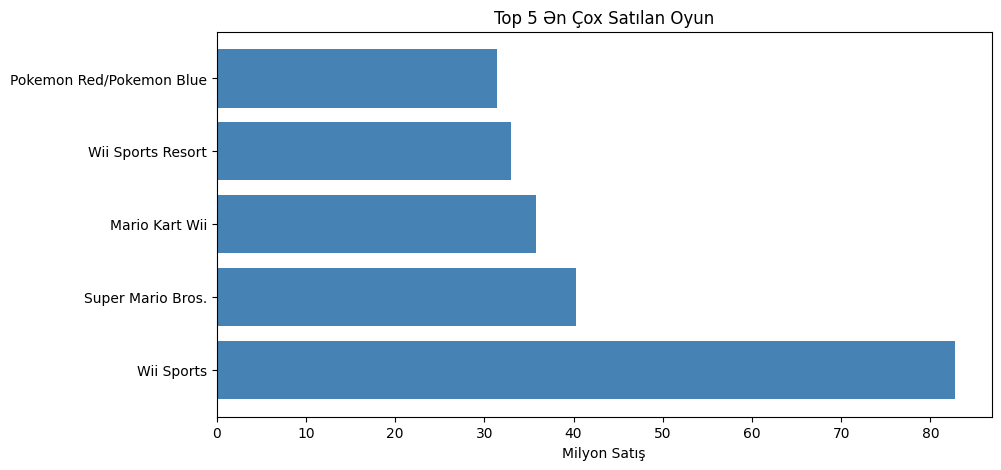

In [ ]:
top_5 = top_10.head(5)

plt.figure(figsize=(10, 5))

plt.barh(top_5['Name'], top_5['Global_Sales'], color='steelblue')

plt.title('Top 5 Ən Çox Satılan Oyun')
plt.xlabel('Milyon Satış')

plt.show()

### TOP OYUN ANALİZİ
Top 5 Ən Çox Satılan Oyun:

* Wii Sports: 82.74 M satış (Wii)

* Super Mario Bros.: 40.24 M satış (NES)

* Mario Kart Wii: 35.82 M satış (Wii)

* Wii Sports Resort: 33.00 M satış (Wii)

* Pokemon Red/Pokemon Blue: 31.37 M satış (GB)


Müşahidə:

* Wii Sports 82.74 milyon satışla bütün zamanların əlçatmaz lideridir.

* Top 10 siyahısındakı bütün oyunların naşiri (Publisher) Nintendo-dur.

* Wii platforması ən çox top oyuna (siyahıda 5 oyun) sahibdir.

* Top oyunların əksəriyyəti retro və hərəkətli sensorlu oyunlar (Wii dövrü) seqmentinə aiddir.



In [ ]:
# Publisher analizi

print("TOP 10 PUBLISHER")
print("=" * 50)

publisher = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)

top_10 = publisher.head(10)

print("Top 10 Şirkət:")

for ad in top_10.index:
    satis = top_10[ad]
    say = len(df[df['Publisher'] == ad])
    print("-", ad, ":", round(satis, 1), "Milyon", "(", say, "oyun)")

TOP 10 PUBLISHER
Top 10 Şirkət:
- Nintendo : 1784.4 Milyon ( 696 oyun)
- Electronic Arts : 1093.4 Milyon ( 1339 oyun)
- Activision : 721.4 Milyon ( 966 oyun)
- Sony Computer Entertainment : 607.3 Milyon ( 682 oyun)
- Ubisoft : 473.5 Milyon ( 918 oyun)
- Take-Two Interactive : 399.3 Milyon ( 412 oyun)
- THQ : 340.4 Milyon ( 712 oyun)
- Konami Digital Entertainment : 278.6 Milyon ( 823 oyun)
- Sega : 270.7 Milyon ( 632 oyun)
- Namco Bandai Games : 253.6 Milyon ( 928 oyun)


### PUBLİSHER ANALİZİ
Top 5 Publisher:

* Nintendo: 1784.4 Milyon satış (696 oyun)

* Electronic Arts: 1093.4 Milyon satış (1339 oyun)

* Activision: 721.4 Milyon satış (966 oyun)

* Sony Computer Entertainment: 607.3 Milyon satış (682 oyun)

* Ubisoft: 473.5 Milyon satış (918 oyun)

Nəticə:

* Nintendo bazarda ən uğurlu publisherdir; EA-dən təxminən iki dəfə az oyun buraxmasına baxmayaraq, satışlarda onu 691 milyon nüsxə fərqlə qabaqlayır.

* Electronic Arts (EA) siyahıda ən çox oyun buraxan (1339 oyun) şirkətdir. Bu, EA-nın illik idman oyunları (FIFA, Madden) və geniş portfolio strategiyasını əks etdirir.

* Top 10 publisher-lərin əksəriyyəti (6-sı: Nintendo, Sony, Konami, Sega, Namco Bandai) Yapon mənşəlidir.

In [ ]:
# Publisher-Platform əlaqəsi


publisher = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)

top_3 = publisher.head(3).index.tolist()

for sirket in top_3:

    sirket_oyunlari = df[df['Publisher'] == sirket]

    platforma_satislari = sirket_oyunlari.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)

    print("---", sirket, "---")
    print("1-ci yer:", platforma_satislari.index[0], "-", platforma_satislari.values[0], "Milyon")
    print("2-ci yer:", platforma_satislari.index[1], "-", platforma_satislari.values[1], "Milyon")
    print("3-cü yer:", platforma_satislari.index[2], "-", platforma_satislari.values[2], "Milyon")
    print()


--- Nintendo ---
1-ci yer: Wii - 390.34 Milyon
2-ci yer: DS - 349.1 Milyon
3-cü yer: GB - 229.06 Milyon

--- Electronic Arts ---
1-ci yer: PS2 - 245.96 Milyon
2-ci yer: X360 - 177.97 Milyon
3-cü yer: PS3 - 167.09 Milyon

--- Activision ---
1-ci yer: X360 - 158.75 Milyon
2-ci yer: PS3 - 126.39 Milyon
3-cü yer: PS2 - 85.59 Milyon



### PUBLISHER-PLATFORM ANALIZI
1. Nintendo:

* Ən güclü: Wii (390.34 M).

* Strategiya: Tamamilə eksklüziv (qapalı) model. Nintendo yalnız öz platformaları (Wii, DS, GB) üçün oyun istehsal edir və bu cihazların satışını öz "hit" oyunları ilə artırır.

2. Electronic Arts (EA):

* Ən güclü: PS2 (245.96 M).

* Strategiya: Multi-platform. EA bazarda olan bütün populyar konsollarda (PlayStation, Xbox) var. Onlar aparat istehsal etmir, sadəcə ən çox satılan cihazlara ən populyar oyunları (məsələn: FIFA) çıxarırlar.

3. Activision:

* Ən güclü: X360 (158.75 M).

* Strategiya: Multi-platform (Xbox meylli). EA kimi çoxsaylı cihazlarda olsa da, Xbox 360 platformasında satışları PlayStation 3-dən daha yüksəkdir (158M vs 126M).

# Hissə 5: Trend və Region Analizi

In [ ]:
#  İllik statistika

# İllərə görə oyun sayını və satışları
oyun_saylari = df.groupby('Year').size().sort_values(ascending=False)
satis_miqdari = df.groupby('Year')['Global_Sales'].sum().sort_values(ascending=False)

#  Ən çox oyun buraxılan il
en_cox_oyun_ili = oyun_saylari.index[0]
en_cox_oyun_sayi = oyun_saylari.values[0]
say_2008 = oyun_saylari[2008]

# 3. Ən çox satış olan il
en_cox_satis_ili = satis_miqdari.index[0]
en_cox_satis_miqdari = satis_miqdari.values[0]
satis_2009 = satis_miqdari[2009]

print("--- İllik Analiz ---")
print("Ən məhsuldar il:", int(en_cox_oyun_ili), "(", en_cox_oyun_sayi, "oyun ) - " , (satis_2009),"Milyon")
print("Ən çox pul qazanılan il:", int(en_cox_satis_ili)," (",(say_2008), "oyun ) - ", round(en_cox_satis_miqdari, 1), "Milyon ")




--- İllik Analiz ---
Ən məhsuldar il: 2009 ( 1431 oyun ) -  667.3 Milyon
Ən çox pul qazanılan il: 2008  ( 1428 oyun ) -  678.9 Milyon 


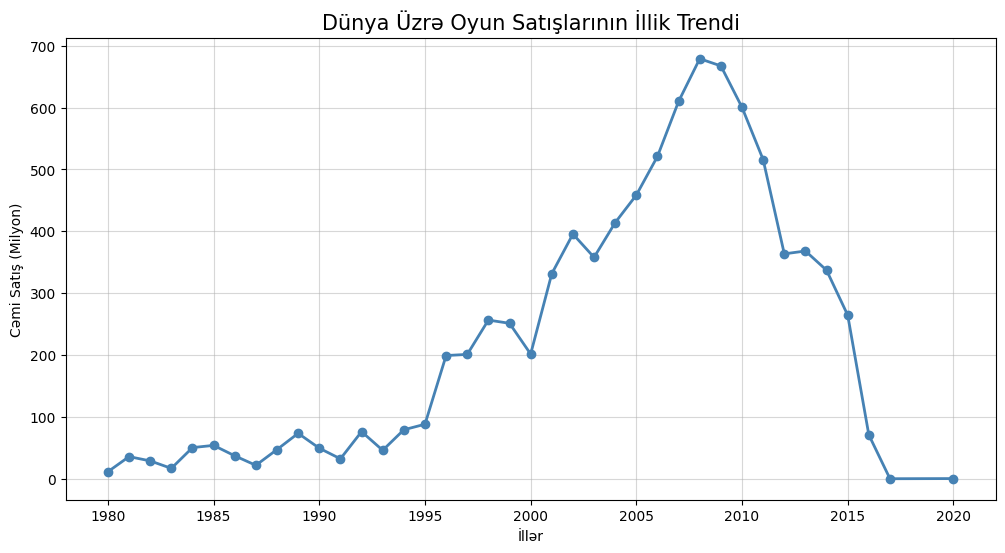

In [ ]:
#İllik Trend Qrafiki

illik_satis = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(12, 6))

plt.plot(illik_satis.index, illik_satis.values, color='steelblue', marker='o', linewidth=2)

plt.title('Dünya Üzrə Oyun Satışlarının İllik Trendi', fontsize=15)
plt.xlabel('İllər')
plt.ylabel('Cəmi Satış (Milyon)')
plt.grid(True, alpha=0.5)

plt.show()

### **İLLİK TREND ANALİZİ**
Oyun Buraxılış Trendi:

* Peak il: 2009-cu il (1431 oyun buraxılıb).

* Trend: 1990-2000-ci illər arasında stabil artım müşahidə olunur. 2000-ci ildən sonra isə sənaye sürətlə böyüyərək 2008-2009-cu illərdə öz zirvəsinə çatıb. 2010-cu ildən sonra isə buraxılan oyun sayında azalma başlayıb.

Satış Trendi:

* Peak satış ili: 2008-ci il (678.9 Milyon dollar/nüsxə satış).

* "Qızıl Era": 2000-2010-cu illər arası video oyun sənayesinin ən güclü dövrüdür. Xüsusilə PS2, Wii və Xbox 360-ın eyni dövrdə aktiv olması satışları rekord həddə çatdırıb.

Nəticə:

* Maraqlıdır ki, ən çox oyun 2009-da çıxsa da, ən çox pul 2008-ci ildə qazanılıb. Bu, 2008-ci ildəki oyunların daha keyfiyyətli və populyar olduğunu göstərir.

* 2012-ci ildən sonrakı kəskin eniş oyunların yox olması deyil, bazarın mobil oyunlara (App Store, Play Store) və rəqəmsal satışlara keçməsi ilə bağlıdır (bu dataset əsasən fiziki disk satışlarını əhatə edir).

* Video oyun sənayesi 2005-2011-ci illər arasında həm kütləvilik, həm də gəlir baxımından ən parlaq dövrünü yaşayıb.

In [ ]:
# Region müqayisəsi

na = df['NA_Sales'].sum()
eu = df['EU_Sales'].sum()
jp = df['JP_Sales'].sum()
os = df['Other_Sales'].sum()

global_cemi = df['Global_Sales'].sum()

na_faiz = (na / global_cemi) * 100
eu_faiz = (eu / global_cemi) * 100
jp_faiz = (jp / global_cemi) * 100
os_faiz = (os / global_cemi) * 100


print("--- Regionların Satış Payı ---")
print("Şimali Amerika:", round(na, 1), "Milyon (", round(na_faiz, 1), "% )")
print("Avropa        :", round(eu, 1), "Milyon (", round(eu_faiz, 1), "% )")
print("Yaponiya      :", round(jp, 1), "Milyon (", round(jp_faiz, 1), "% )")
print("Digər Satışlar :", round(os, 1), "Milyon (", round(os_faiz, 1), "% )")

print("-" * 30)
print("Qlobal Cəmi   :", round(global_cemi, 1), "Milyon")

--- Regionların Satış Payı ---
Şimali Amerika: 4327.7 Milyon ( 49.1 % )
Avropa        : 2406.7 Milyon ( 27.3 % )
Yaponiya      : 1284.3 Milyon ( 14.6 % )
Digər Satışlar : 788.9 Milyon ( 9.0 % )
------------------------------
Qlobal Cəmi   : 8812.0 Milyon


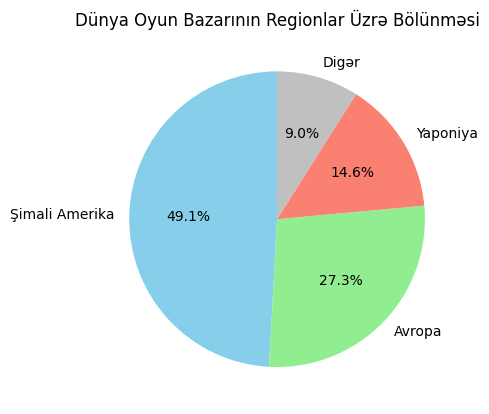

In [ ]:
etiketler = ['Şimali Amerika', 'Avropa', 'Yaponiya', 'Digər']
satislar = [na, eu, jp, os]

plt.pie(satislar, labels=etiketler, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon', 'silver'])
plt.title('Dünya Oyun Bazarının Regionlar Üzrə Bölünməsi')
plt.show()

### Region Payı Analizi
* Şimali Amerika: Bazarın 49.1%-i (Lider).

* Avropa: Bazarın 27.3%-i.

* Yaponiya: Bazarın 14.6%-i.

* Digər: Bazarın 9.0%-i.

Əsas Nəticə:
* Şimali Amerika və Avropa birlikdə qlobal oyun satışlarının 76.4%-ni (təxminən 4-də 3-nü) təşkil edir. Yaponiya isə təkbaşına hər 7 oyundan 1-nin satıldığı strateji bazardır.

#  **ƏN VACİB TAPINTILAR:**

### 1. Platform Analizi

* **PS2** ən uğurlu platformadır (**1233.5 M** satış).
* **2000-2010:** PlayStation (PS2 və PS3) dövrün dominant gücü olub.
* Hər platform orta hesabla **5-7 il** bazarın zirvəsində qalır.

### 2. Genre Seçimləri

* **Action** ən populyar janrdır (**1722.8 M** satış).
* **Region fərqləri:** Yaponiya RPG, Şimali Amerika Action janrını sevir.
* Top 3 janr (Action, Sports, Shooter) ümumi satışın **~46%-ni** təşkil edir.

### 3. Publisher Uğuru

* **Nintendo** lider publisherdir (**1784.4 M** satış).
* Nintendo öz qapalı platformalarında mütləq dominantdır.
* **EA** və **Activision** kimi multi-platform strategiyası geniş kütləyə çatmaq üçün daha uğurludur.

### 4. Bazar Dinamikası

* **North America** ən böyük bazardır (**49.1%**).
* Avropa və Şimali Amerika bir-birinə çox oxşar janr tərcihlərinə malikdir.

* **Yaponiya** unikal bazardır (RPG janrının qlobal trendləri üstələdiyi tək region).

### 5. Trend Analizi

* **2008-ci il** video oyun sənayesinin satış baxımından peak (zirvə) ilidir.
* **1990-2010:** Fiziki oyun satışlarının "Qızıl Erası".
* **2010+:** Bazar rəqəmsal satışlara və mobil oyunlara keçid edib.




